In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ripser import ripser

In [6]:
df = pd.read_csv('archive/1_min_SPY_2008-2021.csv', parse_dates=['date'], index_col='date')
close_prices = df['close'].values

In [7]:
df.head()

,Unnamed: 0,open,high,low,close,volume,barCount,average
date,,,,,,,,
2009-05-22 07:30:00,0,89.45,89.46,89.37,89.37,7872,2102,89.424
2009-05-22 07:31:00,1,89.38,89.53,89.37,89.50,5336,1938,89.468
2009-05-22 07:32:00,2,89.51,89.54,89.48,89.49,3349,1184,89.516
2009-05-22 07:33:00,3,89.49,89.49,89.31,89.34,3495,1240,89.386
2009-05-22 07:34:00,4,89.33,89.46,89.33,89.39,9731,2637,89.379


Rozpoczynam obliczenia TDA dla 4699 okien...
Obliczenia zakończone.


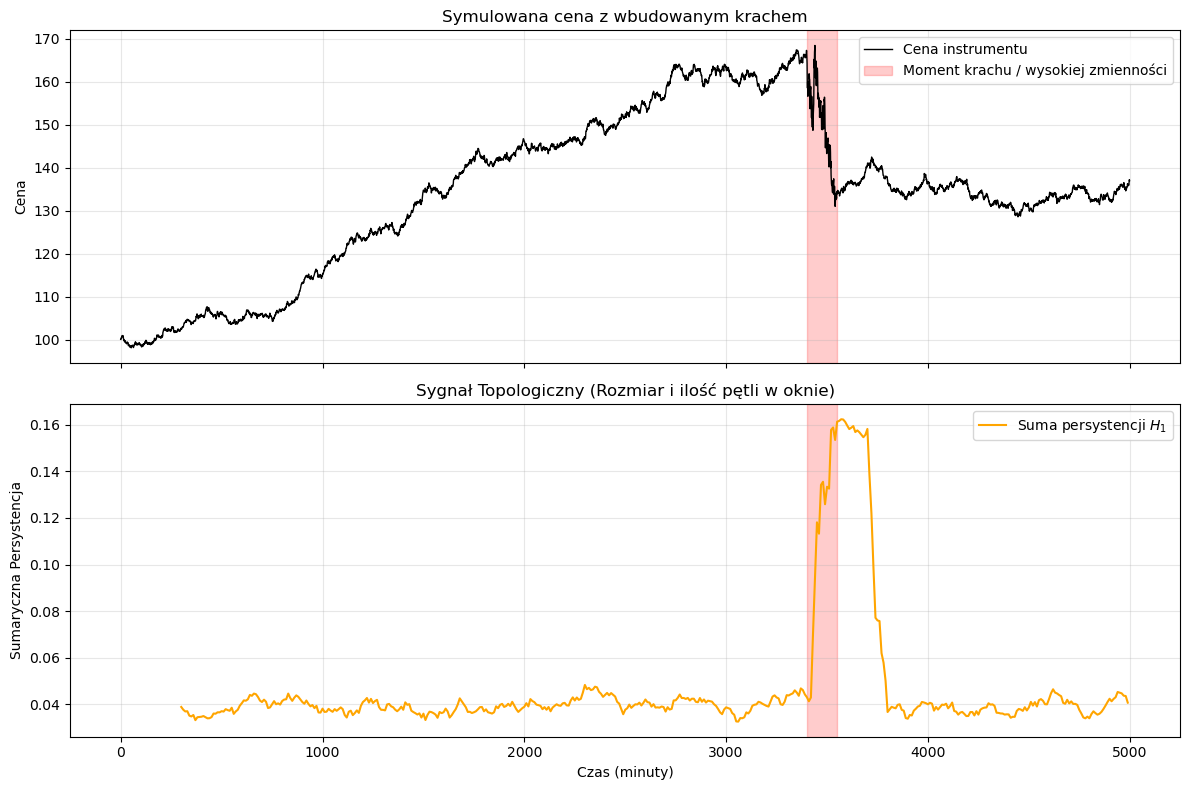

In [10]:
def takens_embedding(series, delay, dimension):
    """
    Tworzy chmurę punktów z jednowymiarowego szeregu czasowego.
    """
    n = len(series) - (dimension - 1) * delay
    if n <= 0:
        return np.array([])
    # Wycinamy przesunięte wektory
    embedded = np.array([series[i : i + dimension * delay : delay] for i in range(n)])
    return embedded



# Na potrzeby testu kodu generujemy syntetyczny geometryczny ruch Browna z "krachem"
np.random.seed(42)
n_points = 5000
returns = np.random.normal(0.0001, 0.002, n_points)
# Symulacja nagłego wzrostu zmienności i krachu w okolicach indeksu 3500
returns[3400:3550] = np.random.normal(-0.002, 0.015, 150) 
close_prices = 100 * np.exp(np.cumsum(returns))

# Obliczamy log-zwroty
log_returns = np.diff(np.log(close_prices))

# 3. Parametry eksperymentu
window_size = 300    # Długość kroczącego okna w minutach
delay = 2            # Opóźnienie (tau) w zanurzeniu Takensa
dimension = 4        # Wymiar chmury punktów (d)
step = 10            # Przesuwamy okno co 10 minut (dla przyspieszenia obliczeń)

# Tablice na wyniki
timestamps = []
h1_total_persistence = []

print(f"Rozpoczynam obliczenia TDA dla {len(log_returns) - window_size} okien...")

# 4. Główna pętla
for i in range(0, len(log_returns) - window_size, step):
    window_data = log_returns[i : i + window_size]
    
    # Tworzymy chmurę punktów
    point_cloud = takens_embedding(window_data, delay, dimension)
    
    if len(point_cloud) < dimension + 1:
        continue # Pomijamy, jeśli mamy za mało punktów
        
    # Obliczamy homologię persystentną (interesuje nas max wymiar 1)
    # ripser radzi sobie najlepiej z macierzami odległości, 
    # ale przyjmuje też chmury punktów i sam liczy metrykę euklidesową
    res = ripser(point_cloud, maxdim=1)
    diagrams = res['dgms']
    
    # Diagram dla H_1 (pętle)
    h1_diagram = diagrams[1]
    
    if len(h1_diagram) > 0:
        # Filtrujemy cechy o nieskończonym czasie życia (choć w H_1 rzadkie)
        valid_features = h1_diagram[h1_diagram[:, 1] != np.inf]
        if len(valid_features) > 0:
            # Obliczamy "czas życia" (death - birth) każdej pętli
            lifespans = valid_features[:, 1] - valid_features[:, 0]
            # Sumujemy czasy życia jako prostą miarę (proxy entropii L1)
            total_pers = np.sum(lifespans)
        else:
            total_pers = 0.0
    else:
        total_pers = 0.0
        
    h1_total_persistence.append(total_pers)
    # Zapisujemy indeks środka lub końca okna do wykresu
    timestamps.append(i + window_size)

print("Obliczenia zakończone.")

# 5. Wizualizacja
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Wykres cen
ax1.plot(close_prices, label='Cena instrumentu', color='black', linewidth=1)
ax1.axvspan(3400, 3550, color='red', alpha=0.2, label='Moment krachu / wysokiej zmienności')
ax1.set_title('Symulowana cena z wbudowanym krachem')
ax1.set_ylabel('Cena')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Wykres sygnału topologicznego
ax2.plot(timestamps, h1_total_persistence, label='Suma persystencji $H_1$', color='orange', linewidth=1.5)
ax2.set_title('Sygnał Topologiczny (Rozmiar i ilość pętli w oknie)')
ax2.set_xlabel('Czas (minuty)')
ax2.set_ylabel('Sumaryczna Persystencja')
ax2.axvspan(3400, 3550, color='red', alpha=0.2)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()